<a href="https://colab.research.google.com/github/jesus-bazan-entel/jesus-bazan.github.io/blob/main/VoiceEmbeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Interactive Colab Notebook for Voice Embeddings**

Today we’ll walk through this notebook end to end: we will record voice samples, extract speaker embeddings, compare voices across people using cosine distance, and visualize the similarity structure with UMAP to see how speakers cluster and separate.

## **0. Setup**

This cell installs everything we need for the session: voice embedding extraction (resemblyzer), recording support, and the core math stack (numpy, scipy), with quiet output so the notebook stays clean. Simply, start by running the following code.

In [3]:
!pip -q install resemblyzer sounddevice numpy scipy --progress-bar off

  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done


Here we load the tools we’ll use throughout: saving audio to WAV, handling arrays, creating speaker embeddings, playing audio in the notebook, and computing cosine distance for voice similarity.

In [4]:
from scipy.io.wavfile import write
import numpy as np
from resemblyzer import VoiceEncoder, preprocess_wav
import os
from google.colab import files
from IPython.display import Audio
import scipy.io.wavfile as wav
from scipy.spatial.distance import cosine

Now, let's define a handy recorder in **Javascript** that asks for microphone access, records for a set number of seconds, collects the audio chunks, and returns the recording back into Python so we can embed it and compare voices right away.

In [5]:
from IPython.display import display, Javascript, HTML, Audio

def record_audio_js(filename, seconds):
    display(HTML('''
    <script>
    const sleep = time => new Promise(resolve => setTimeout(resolve, time))
    const b2text = blob => new Promise(resolve => {
        const reader = new FileReader();
        reader.onloadend = () => resolve(reader.result);
        reader.readAsDataURL(blob);
    });

    async function record(filename, sec=seconds){
        const stream = await navigator.mediaDevices.getUserMedia({ audio: true });
        const mediaRecorder = new MediaRecorder(stream);
        const audioChunks = [];

        mediaRecorder.ondataavailable = event => {
            audioChunks.push(event.data);
        };

        mediaRecorder.start();
        await sleep(sec * 1000);
        mediaRecorder.stop();

        await new Promise(resolve => mediaRecorder.onstop = resolve);

        const audioBlob = new Blob(audioChunks);
        const audioUrl = URL.createObjectURL(audioBlob);
        const a = document.createElement("a");
        a.style.display = "none";
        a.href = audioUrl;
        a.download = filename;
        document.body.appendChild(a);
        a.click();
        await sleep(1000);
        document.body.removeChild(a);
    }

    record("filxx", sec=secxx);
    </script>
    <p>🎙️</p>
    '''.replace("filxx", filename).replace("secxx", str(seconds))))


## **1. Training Set**

Run these two cells in order to build your first tiny “training set” recording.

### **Step 1: Quick mic and encoder check**


1. Run the first cell `record_audio_js("test_name.wav", 3)`.
2. Your browser will pop up a microphone permission request. Click **Allow**.
3. Speak the short line shown in the cell while it records for 3 seconds.
4. When it finishes, the notebook will save the audio as `test_name.wav` and you should see a download prompt at the end. This is just a fast sanity check that recording works before we do the longer passage.


In [8]:
record_audio_js("test_name.wav", 3)

#dura 3s
leer="""
Hello, my name is ...
"""
print(leer)


Hello, my name is ...



### **Step 2: The real sample with Ovid’s Echo**

1. Run the second cell `record_audio_js("test_echo.wav", 20)`.
2. Again, allow microphone access if asked.
3. Read the full Echo passage at a natural pace for the full 20 seconds.
4. At the end, the notebook saves `test_echo.wav` and you will download it. This longer clip gives the encoder enough signal to produce a cleaner, more stable embedding.

In [14]:
record_audio_js("test_echo.wav", 20)

#dura 20s
leer="""
the poet Ovid tells of Juno and the jealousy she felt over her husband Jupiter's many affairs.
Though vigilant, whenever she was about to catch him, Echo distracted her with lengthy conversations.
When at last Juno realized the truth, she cursed Echo.
From that moment on, the once loquacious nymph could only repeat the most recently spoken words of another person.
"""
print(leer)


the poet Ovid tells of Juno and the jealousy she felt over her husband Jupiter's many affairs.
Though vigilant, whenever she was about to catch him, Echo distracted her with lengthy conversations.
When at last Juno realized the truth, she cursed Echo.
From that moment on, the once loquacious nymph could only repeat the most recently spoken words of another person.



### **Step 3: Preprocess the recording (clean + standardize)**

Run this cell to preprocess your `test_echo.wav` using `preprocess_wav` and save it as `processed_test_echo.wav` at 16 kHz.

**What this does**
- Cleans the audio (trim / normalize / reduce silence effects)
- Standardizes format so embeddings are more stable and comparable
- Writes a new file: `processed_test_echo.wav`

**Important note**
- You may see warnings about `PySoundFile` or `librosa` deprecations. These are common in Colab and you can ignore them for this notebook.

In [15]:
ejercicio1_pre = preprocess_wav("test_echo.wav")
output_filename = "processed_test_echo.wav"
wav.write(output_filename, 16000, ejercicio1_pre)


/usr/local/lib/python3.12/dist-packages/resemblyzer/audio.py:27: UserWarning: PySoundFile failed. Trying audioread instead.
  wav, source_sr = librosa.load(str(fpath_or_wav), sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


### **Upload checkpoint (do this right after Step 3)**


Before moving on, make sure the preprocessed file is available in your session.

**If you recorded in this same Colab session**
- You already have `processed_test_echo.wav` in the file system, so you can proceed.

**If you are continuing in a fresh session or from someone else’s file**
1. Upload your preprocessed file into Colab (`processed_test_echo.wav`).
2. Confirm it appears in the file browser (left panel) before running Step 4.

### **Step 4: Split the preprocessed audio into parts**

Now run the next cell to split `processed_test_echo.wav` into multiple smaller WAV files (e.g., `sample_0.wav`, `sample_1.wav`, …).

**Why we split**
- Smaller chunks give you multiple embedding samples per person
- That makes comparisons more robust, and helps UMAP show clearer structure

In [16]:
from pydub import AudioSegment

audio = AudioSegment.from_wav("processed_test_echo.wav")

duration = len(audio)
segment_length = duration // 5

for i in range(5):
    start = i * segment_length
    end = start + segment_length
    segment = audio[start:end]
    segment.export(f"sample_{i}.wav", format="wav")

/usr/local/lib/python3.12/dist-packages/pydub/utils.py:300: SyntaxWarning: invalid escape sequence '\('
  m = re.match('([su]([0-9]{1,2})p?) \(([0-9]{1,2}) bit\)$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:301: SyntaxWarning: invalid escape sequence '\('
  m2 = re.match('([su]([0-9]{1,2})p?)( \(default\))?$', token)
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:310: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(flt)p?( \(default\))?$', token):
/usr/local/lib/python3.12/dist-packages/pydub/utils.py:314: SyntaxWarning: invalid escape sequence '\('
  elif re.match('(dbl)p?( \(default\))?$', token):


### **Step 5: Load the speaker encoder**


Run this cell to initialize the `VoiceEncoder`.  
This loads the pretrained model we’ll use to turn each audio clip into a fixed-length voice embedding.

In [17]:
encoder = VoiceEncoder()

Loaded the voice encoder model on cpu in 0.05 seconds.


### **Step 6: Define a tiny helper to normalize embeddings**

This defines `l2norm(v)`, which rescales an embedding to unit length. Why we do this: cosine distance behaves more consistently when vectors are normalized, so comparisons are fairer.


In [18]:
def l2norm(v, eps=1e-9):
    return v / (np.linalg.norm(v) + eps)

### **Step 7: Create embeddings for each audio chunk**

This cell loops over your split clips (`sample_0.wav`, `sample_1.wav`, …), and for each one:
1. preprocesses the waveform again (quick cleanup and standardization),
2. extracts an embedding with `encoder.embed_utterance(...)`,
3. normalizes it with `l2norm`,
4. stores it in the `samples` list.

In [19]:
samples=[]
for k in range(5):
  ejercicio1_pre = preprocess_wav(f"sample_{k}.wav")
  ejercicio1_embed = encoder.embed_utterance(ejercicio1_pre)
  ejercicio1_embed_norm=l2norm(ejercicio1_embed)
  samples.append(ejercicio1_embed_norm)

### **Step 8: Build the pairwise cosine-distance matrix**

This last cell compares every embedding to every other embedding and fills a square matrix (`mat`).  
Interpretation: smaller distance means the clips sound more like the same speaker, larger distance means they sound less alike.

**Sanity check**
- The diagonal should be ~0 (each clip compared to itself).
- The matrix should be symmetric (comparison works both ways).

In [20]:
mat=np.zeros((5,5))
for i1,s1 in enumerate(samples):
  for i2,s2 in enumerate(samples):
    sim=cosine(s1, s2)
    mat[i1,i2]=sim

<Axes: >

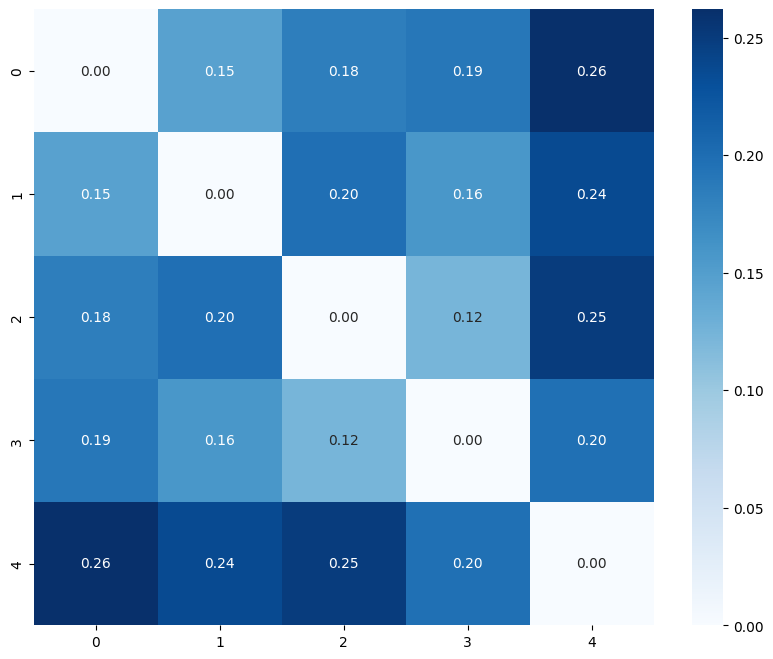

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
sns.heatmap(mat,  cmap="Blues", annot=True, fmt=".2f")


### **Step 9: Create a master embedding by taking averages**

In [22]:
master_embedding=np.mean(samples, axis=0)

## **2. Test Set**

Now we’ll record a second 20-second clip (`test_echo_2.wav`) using a different phrase. Run this cell, allow microphone access if prompted, and read the text out loud to create the test-set recording.

In [25]:
record_audio_js("test_echo_2.wav", 20)

#dura 20s
leer="""
Sometime after being cursed, Echo spied a young man, Narcissus, while he was out hunting deer with his companions.
She immediately fell in love with him and, infatuated, followed quietly.
The more she looked at the young man, the more she longed for him.
Though she wished with all her heart to call out to Narcissus, Juno's curse prevented her."""
print(leer)


Sometime after being cursed, Echo spied a young man, Narcissus, while he was out hunting deer with his companions.
She immediately fell in love with him and, infatuated, followed quietly.
The more she looked at the young man, the more she longed for him.
Though she wished with all her heart to call out to Narcissus, Juno's curse prevented her.


Upload `test_echo_2.wav` to files and run the following chunk to replicate the initial steps for this new sample.

In [26]:
bits=10

ejercicio1_pre = preprocess_wav("test_echo_2.wav")
output_filename = "processed_test_echo2.wav"
wav.write(output_filename, 16000, ejercicio1_pre)

audio = AudioSegment.from_wav("processed_test_echo2.wav")

duration = len(audio)
segment_length = duration // bits

for i in range(bits):
    start = i * segment_length
    end = start + segment_length
    segment = audio[start:end]
    segment.export(f"sample2_{i}.wav", format="wav")


samples2=[]
for k in range(bits):
  ejercicio1_pre = preprocess_wav(f"sample2_{k}.wav")
  ejercicio1_embed = encoder.embed_utterance(ejercicio1_pre)
  ejercicio1_embed_norm=l2norm(ejercicio1_embed)
  samples2.append(ejercicio1_embed_norm)

/usr/local/lib/python3.12/dist-packages/resemblyzer/audio.py:27: UserWarning: PySoundFile failed. Trying audioread instead.
  wav, source_sr = librosa.load(str(fpath_or_wav), sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)


### **Compare Test Set to Training Set**

This cell takes the embeddings from your test clip (`samples2`) and measures cosine distance against:

1. **Each individual training chunk** (`samples[0]` to `samples[4]`)  
2. A **single “master” training voice** made by averaging all training embeddings (`master_embedding`)

It then plots all distances as a scatter plot where **lower cosine distance = more similar voice**. The last x-axis label (`master`) shows how close the test clip is to the overall training reference.

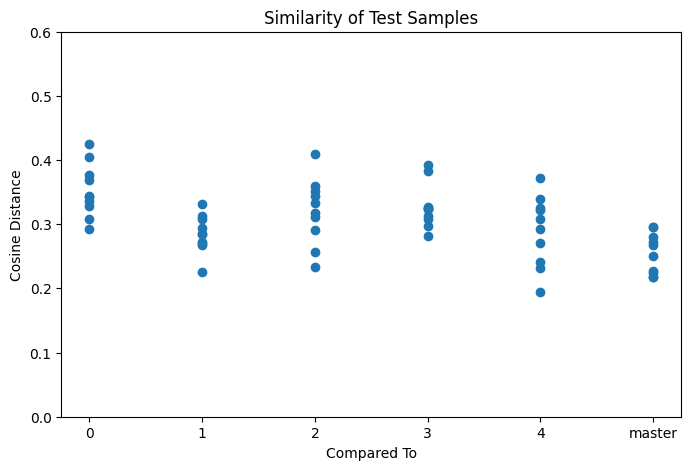

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.distance import cosine


x_vals = []
y_vals = []

# 1️⃣ Sample-to-sample similarities (samples2 vs samples)
for i_test, s_test in enumerate(samples2):
    for i_ref, s_ref in enumerate(samples):
        sim = cosine(s_test, s_ref)
        x_vals.append(i_ref)  # compared to sample 0-4
        y_vals.append(sim)

# 2️⃣ Sample-to-master similarities
master_embedding = l2norm(np.mean(samples, axis=0))

for s_test in samples2:
    sim = cosine(s_test, master_embedding)
    x_vals.append(5)  # master index
    y_vals.append(sim)

# Plot
plt.figure(figsize=(8,5))
plt.scatter(x_vals, y_vals)

plt.xticks([0,1,2,3,4,5], ['0','1','2','3','4','master'])
plt.ylabel("Cosine Distance")
plt.xlabel("Compared To")
plt.title("Similarity of Test Samples")
plt.ylim(0,0.6)

plt.show()


## **3. Upload Your Recordings (run once)**

Run these cells **one time** to upload your embeddings to the shared sheet/database:

- The first cell uploads your **master embedding** (your averaged training voice).
- The second cell uploads all **test-set embeddings** from `samples2` (your `test_echo_2` chunks).

Make sure the `name = "..."` field matches your name before running.

In [28]:
name = "Jesus"

In [29]:
import requests

url = "https://script.google.com/macros/s/AKfycbw6vuBkMb6Jcs_bZfyn39vtwB5dzo_ves5oMxCSUDeF_Vw0fHvrYupJoSFumNIV-XFU/exec"

payload = {
    "name": name,
    "type":"master",
    "index":0,
    "embedding": master_embedding.tolist()
}

r = requests.post(url, json=payload)

print(r.text)

Success


In [30]:
import requests

url = "https://script.google.com/macros/s/AKfycbw6vuBkMb6Jcs_bZfyn39vtwB5dzo_ves5oMxCSUDeF_Vw0fHvrYupJoSFumNIV-XFU/exec"

for i, emb in enumerate(samples2):
    payload = {
        "type": "echo2",
        "name": name,
        "index": i,
        "embedding": emb.tolist()
    }

    r = requests.post(url, json=payload)
    print(i)

print("Uploaded all echo2 samples.")

0
1
2
3
4
5
6
7
8
9
Uploaded all echo2 samples.


## **4. Distance to Test Sample to Their Master**

Run these two cells to compare your test-set embeddings (`samples2`) against everyone’s uploaded **master embedding**.

- **Cell 1** loads the shared spreadsheet of master embeddings into `names` and `embeddings`.
- **Cell 2** computes cosine distance from each test embedding to each master, then plots the results (one cluster of points per name). Lower values mean the test voice is closer to that person’s master reference.

In [31]:
import pandas as pd
import json
import numpy as np

SHEET_ID = "12sCFsXpMgm_MCe1wL-h6z7M8GP5kRxtCDOht3wa8qCI"
GID = "0"

csv_url = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=csv&gid={GID}"

df = pd.read_csv(csv_url)

# Expect columns: Name, Embedding (Embedding is a JSON list string)
names = df["Name"].astype(str).tolist()
embeddings = [np.array(json.loads(s), dtype=np.float32) for s in df["Embedding"].astype(str).tolist()]

print("Loaded:", len(embeddings), "embeddings")
print("Example:", names[0], embeddings[0].shape, embeddings[0][:5])

Loaded: 12 embeddings
Example: Umutcan (256,) [0.02368502 0.0015555  0.00460428 0.         0.01276588]


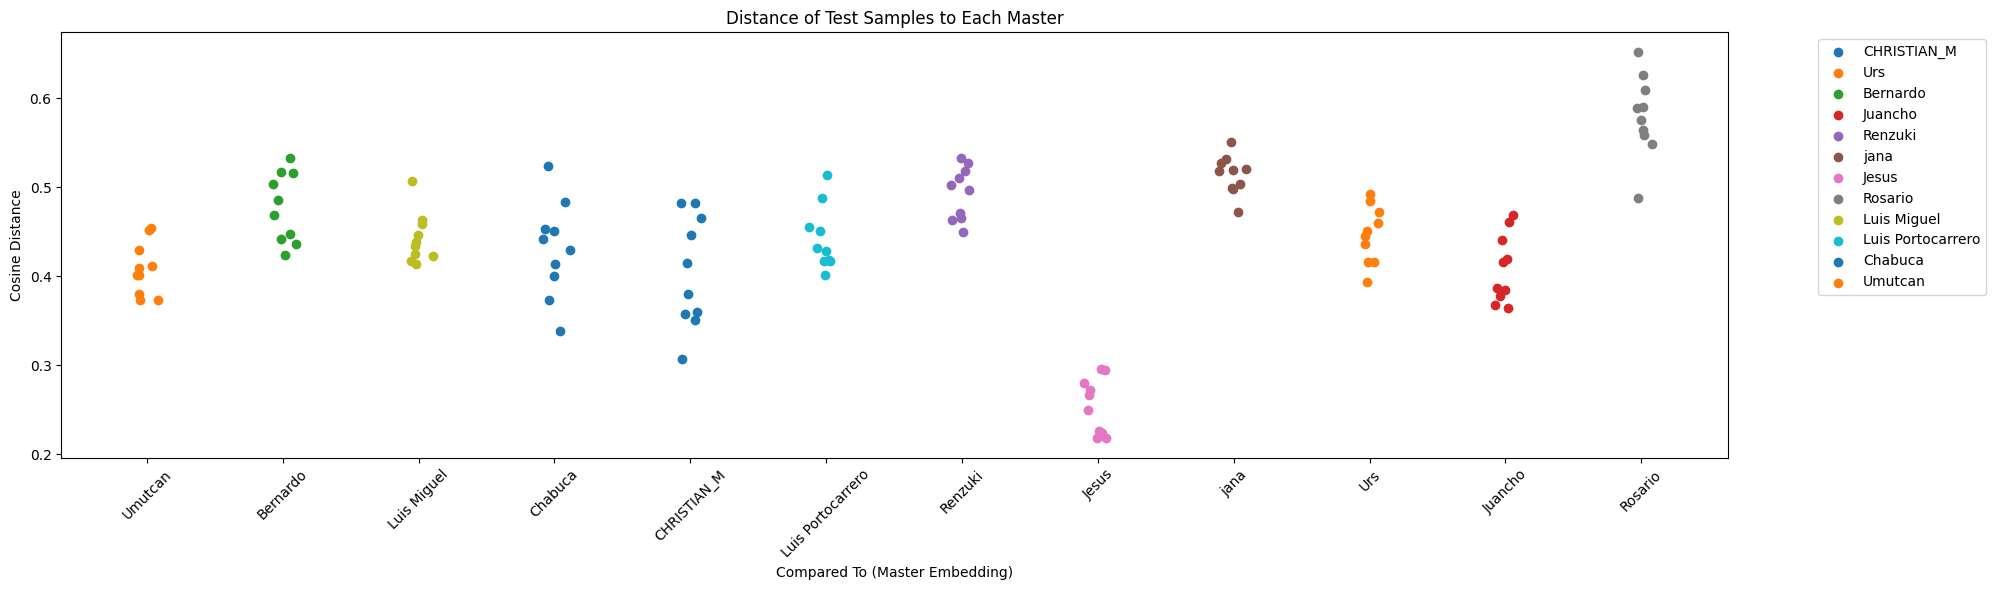

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial.distance import cosine

x_vals = []
y_vals = []
labels = []

for test_embed in samples2:
    for i, master in enumerate(embeddings):
        dist = cosine(test_embed, master)
        x_vals.append(i)
        y_vals.append(dist)
        labels.append(names[i])

x_vals = np.array(x_vals)
y_vals = np.array(y_vals)

# Add small jitter so points don't stack exactly
x_vals_jitter = x_vals + np.random.normal(0, 0.05, size=len(x_vals))

plt.figure(figsize=(20,6))

unique_names = list(set(labels))

for name in unique_names:
    mask = np.array(labels) == name
    plt.scatter(x_vals_jitter[mask], y_vals[mask], label=name)

plt.xticks(range(len(names)), names, rotation=45)
plt.ylabel("Cosine Distance")
plt.xlabel("Compared To (Master Embedding)")
plt.title("Distance of Test Samples to Each Master")
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.tight_layout()
plt.show()


## **5. Using UMAP to Show Differences Across Embeddings**

### **What is UMAP and why use it here?**

**UMAP** (Uniform Manifold Approximation and Projection) is a dimensionality-reduction method that maps high-dimensional vectors (like voice embeddings with hundreds of dimensions) into **2D** or **3D** while trying to preserve the **local neighborhood structure** of the original space.

### **Why it's useful for voice embeddings?**

- **Quick visual sanity check:** If embeddings are meaningful, clips from the same person often cluster together, while different speakers tend to separate.
- **Explore similarity:** Points that appear close in the UMAP plot are typically **more similar** in the embedding space (under the chosen distance metric, here cosine).
- **Spot outliers and label issues:** Helps reveal mislabeled samples, unusual recordings, or speakers whose samples don’t group as expected.
- **Communicate patterns:** A 2D plot is an intuitive way to present structure in embeddings to others.

In [37]:
#load all embeddings in samples
import pandas as pd
import json
import numpy as np

SHEET_ID = "12sCFsXpMgm_MCe1wL-h6z7M8GP5kRxtCDOht3wa8qCI"
GID = "261083039"

csv_url = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=csv&gid={GID}"

df = pd.read_csv(csv_url)

# Expect columns: Name, Embedding (Embedding is a JSON list string)
names_all = df["Name"].astype(str).tolist()
embeddings_all = [np.array(json.loads(s), dtype=np.float32) for s in df["Embedding"].astype(str).tolist()]

print("Loaded:", len(embeddings_all), "embeddings")
print("Example:", names_all[0], embeddings_all[0].shape, embeddings_all[0][:5])

Loaded: 160 embeddings
Example: Bernardo (256,) [0.         0.         0.12115299 0.         0.        ]


In [40]:
import plotly.express as px
from plotly import graph_objects as go
from sklearn.manifold import TSNE
import umap
import numpy as np
import pandas as pd
import json


In [41]:

# -----------------------
# LOAD DATA
# -----------------------
df = pd.read_csv(csv_url)

required_cols = {"Name", "Embedding"}
missing = required_cols - set(df.columns)
if missing:
    raise ValueError(f"Missing required columns: {missing}. Found columns: {list(df.columns)}")

names = df["Name"].astype(str).to_numpy()

# Parse embeddings
emb_list = []
bad_rows = []
for i, s in enumerate(df["Embedding"].astype(str).tolist()):
    try:
        v = np.array(json.loads(s), dtype=np.float32)
        emb_list.append(v)
    except Exception as e:
        bad_rows.append((i, str(e)))

if bad_rows:
    print("WARNING: Some rows could not be parsed as JSON embeddings:")
    for r, msg in bad_rows[:10]:
        print(f"  Row {r}: {msg}")
    raise ValueError("Fix embedding parse errors (or drop bad rows) and rerun.")

dims = [v.shape[0] for v in emb_list]
if len(set(dims)) != 1:
    dim_counts = pd.Series(dims).value_counts().sort_index()
    print("Embedding dimension counts:\n", dim_counts)
    raise ValueError("Not all embeddings have the same length. Fix/clean your Embedding column.")

X = np.vstack(emb_list)
n = X.shape[0]
print("Loaded:", n, "embeddings with dim:", X.shape[1])

# -----------------------
# SHARED STYLE: limited colors + cycle symbols (50+ people)
# -----------------------
uniq = pd.unique(df["Name"].astype(str))

palette = px.colors.qualitative.Safe  # 11 colors
COLOR_LIMIT = len(palette)

symbols = [
    "circle", "square", "diamond", "cross", "x",
    "triangle-up", "triangle-down", "triangle-left", "triangle-right",
    "star", "hexagon", "pentagon",
    "hourglass", "bowtie",
    "circle-open", "square-open", "diamond-open",
    "triangle-up-open", "triangle-down-open",
    "star-open", "hexagon-open"
]

def style_for_label(i: int):
    color = palette[i % COLOR_LIMIT]
    symbol = symbols[(i // COLOR_LIMIT) % len(symbols)]
    return color, symbol

label_to_style = {lab: style_for_label(i) for i, lab in enumerate(uniq)}

def make_interactive_scatter(df_xy: pd.DataFrame, xcol: str, ycol: str, title: str) -> go.Figure:
    fig = go.Figure()
    for lab in uniq:
        sub = df_xy[df_xy["Name"].astype(str) == lab]
        color, symbol = label_to_style[lab]
        fig.add_trace(
            go.Scatter(
                x=sub[xcol],
                y=sub[ycol],
                mode="markers",
                name=str(lab),
                marker=dict(color=color, symbol=symbol, size=11, line=dict(width=0)),
                text=sub["Name"].astype(str),
                hovertemplate=(
                    "Name: %{text}<br>"
                    f"{xcol}: %{{x:.3f}}<br>"
                    f"{ycol}: %{{y:.3f}}<extra></extra>"
                ),
            )
        )

    fig.update_layout(
        title=title,
        xaxis_title=xcol,
        yaxis_title=ycol,
        legend_title="Name",
        template="plotly_white",
        width=900,
        height=600,
        margin=dict(l=40, r=240, t=60, b=40),
    )
    return fig

# -----------------------
# UMAP (tiny-N safe)
# -----------------------
n_neighbors = max(2, min(15, n - 1)) if n > 2 else 1

reducer = umap.UMAP(
    n_neighbors=n_neighbors,
    n_components=2,
    min_dist=0.1,
    metric="cosine",
    init="random",
    random_state=42
)
Z_umap = reducer.fit_transform(X)

df_out = df.copy()
df_out["umap1"] = Z_umap[:, 0]
df_out["umap2"] = Z_umap[:, 1]

fig_umap = make_interactive_scatter(df_out.assign(Name=names), "umap1", "umap2",
                                    "UMAP of Voice Embeddings (interactive)")
fig_umap.show()

Loaded: 160 embeddings with dim: 256


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


### **How to interpret the plot (important caveats)**

- **Local > global:** UMAP is best at preserving **local** relationships (who is near whom). The **global geometry** (exact distances between far-apart clusters) is less reliable.
- **Axes have no meaning:** “UMAP-1” and “UMAP-2” are arbitrary coordinates—not interpretable features.
- **Stochastic output:** Results can change with randomness and parameter choices (e.g., `n_neighbors`, `min_dist`). We fix `random_state` for reproducibility.
- **Clusters ≠ proof:** Clustering in 2D suggests structure but doesn’t prove separability; always validate with quantitative metrics if needed.

In short, UMAP is a practical tool to **visualize and explore** the structure of voice embeddings, check whether samples from the same speaker form coherent groups, and identify anomalies before deeper analysis.

## **T-SNE and How it Differ from UMAP**

Both **UMAP** and **t-SNE** are nonlinear dimensionality-reduction methods used to visualize high-dimensional embeddings (e.g., voice embeddings) in **2D**. They are primarily **exploratory** tools: great for sanity checks, spotting outliers, and communicating structure, but not definitive evidence of separability.

In [42]:
# -----------------------
# t-SNE (interactive)
# -----------------------
# Practical defaults:
# - perplexity must be < n, and usually works best in [5, 50] for moderate n.
# - for very small n, set a tiny perplexity.
if n < 3:
    raise ValueError("t-SNE needs at least 3 points to be meaningful.")
perplexity = min(30, max(2, (n - 1) // 3))          # simple heuristic
perplexity = min(perplexity, n - 1 - 1e-6)          # ensure < n

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    metric="cosine",
    init="random",
    learning_rate="auto",
    random_state=42
)
Z_tsne = tsne.fit_transform(X)

df_out["tsne1"] = Z_tsne[:, 0]
df_out["tsne2"] = Z_tsne[:, 1]

fig_tsne = make_interactive_scatter(df_out.assign(Name=names), "tsne1", "tsne2",
                                    f"t-SNE of Voice Embeddings (interactive, perplexity={perplexity})")
fig_tsne.show()

# -----------------------
# SAVE RESULTS (both UMAP + t-SNE)
# -----------------------
out_path = "embeddings_2d_umap_tsne.csv"
df_out.to_csv(out_path, index=False)
print(f"Saved 2D coordinates to: {out_path}")

Saved 2D coordinates to: embeddings_2d_umap_tsne.csv


### **What they try to preserve**

- **t-SNE**: prioritizes **very local neighborhoods**. It is excellent at showing which points are immediate neighbors, often producing visually clean clusters.
- **UMAP**: also preserves local neighborhoods, but does so via a **k-nearest-neighbor graph** objective that often retains *more* medium-scale structure than t-SNE (depending on parameters).

### **Key differences in practice**


- **Global distances are not reliable in either plot.**
  - In both methods, the *distance between far-apart clusters* can be misleading.
- **t-SNE tends to emphasize cluster “islands”.**
  - It often forms well-separated blobs even when the underlying data has continuous structure; empty space between clusters can be an artifact.
- **UMAP often gives sharper separation *or* more continuity depending on settings.**
  - With small `min_dist`, UMAP can pack points tightly within groups and leave visible gaps between groups.

### **Why UMAP can appear to “exaggerate differences”**


UMAP is not literally measuring “difference” on its axes; rather, its **optimization objective** can yield layouts where:
- **Within-cluster points are pulled closer** (especially with low `min_dist`), while
- **Between-cluster regions look emptier** due to repulsion and how the graph layout is optimized in 2D.

This can make groups look more distinct than you might expect from the raw embedding space. The effect is strongest when:
- `min_dist` is small (tighter packing),
- `n_neighbors` is small (more local emphasis),
- the data naturally contains density variations.

### **How to interpret responsibly**

- Treat both UMAP and t-SNE as **maps of neighborhood structure**, not as literal geometry.
- If you see separation, validate it with quantitative checks (e.g., nearest-neighbor classification accuracy, clustering metrics, or speaker verification performance).
- For stability, fix seeds (`random_state`) and report parameter choices (`n_neighbors`, `min_dist` for UMAP; `perplexity` for t-SNE).

In short: **t-SNE is a strong local “cluster viewer”**, while **UMAP is a flexible neighborhood-preserving map** that can look more separated depending on how tightly it is allowed to pack points.

## **6. Test the Recognizer**

1. Run `record_audio_js("final_rec.wav", 3)`, allow microphone access, and speak naturally for 3 seconds.
2. Run the next cell to preprocess the clip and extract a normalized embedding.
3. Run the final cell to compare your embedding to everyone’s uploaded master voices and print a ranked list of closest matches (lowest cosine distance wins).

In [43]:
record_audio_js("final_rec.wav", 3)

In [45]:
import pandas as pd
import json
import numpy as np

SHEET_ID = "12sCFsXpMgm_MCe1wL-h6z7M8GP5kRxtCDOht3wa8qCI"
GID = "0"

csv_url = f"https://docs.google.com/spreadsheets/d/{SHEET_ID}/export?format=csv&gid={GID}"

df = pd.read_csv(csv_url)

# Expect columns: Name, Embedding (Embedding is a JSON list string)
names = df["Name"].astype(str).tolist()
embeddings = [np.array(json.loads(s), dtype=np.float32) for s in df["Embedding"].astype(str).tolist()]

print("Loaded:", len(embeddings), "embeddings")
print("Example:", names[0], embeddings[0].shape, embeddings[0][:5])

Loaded: 17 embeddings
Example: Umutcan (256,) [0.02368502 0.0015555  0.00460428 0.         0.01276588]


In [46]:
ejercicio1_pre = preprocess_wav("final_rec.wav")
ejercicio1_embed = encoder.embed_utterance(ejercicio1_pre)
embedding_normalized=l2norm(ejercicio1_embed)

/usr/local/lib/python3.12/dist-packages/resemblyzer/audio.py:27: UserWarning:

PySoundFile failed. Trying audioread instead.

/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning:

librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.



In [47]:
from scipy.spatial.distance import cosine
import numpy as np
import pandas as pd

# Ensure final embedding is float32 and normalized (just in case)
final_emb = np.array(embedding_normalized, dtype=np.float32)
final_emb = final_emb / (np.linalg.norm(final_emb) + 1e-9)

# Also normalize masters (in case any weren't stored normalized)
masters = []
for e in embeddings:
    e = np.array(e, dtype=np.float32)
    e = e / (np.linalg.norm(e) + 1e-9)
    masters.append(e)

# Compute distances + similarities
rows = []
for n, master in zip(names, masters):
    dist = cosine(final_emb, master)          # 0 is identical, higher is worse
    sim = 1.0 - dist                          # higher is better
    rows.append((n, float(dist), float(sim)))

# Rank by best match (smallest distance)
df_rank = pd.DataFrame(rows, columns=["Speaker", "Cosine Distance", "Cosine Similarity"])
df_rank = df_rank.sort_values("Cosine Distance").reset_index(drop=True)

print("\n===== FINAL REC: SPEAKER RANKING (vs GID=0 masters) =====\n")
print(df_rank.head(10))  # top 10


===== FINAL REC: SPEAKER RANKING (vs GID=0 masters) =====

    Speaker  Cosine Distance  Cosine Similarity
0     Jesus         0.265685           0.734315
1   Umutcan         0.355720           0.644280
2   Juancho         0.406869           0.593131
3    Melisa         0.413486           0.586514
4  Bernardo         0.443428           0.556572
5       ...         0.448415           0.551585
6       ...         0.448415           0.551585
7       ...         0.448415           0.551585
8    Johana         0.448415           0.551585
9       Urs         0.458143           0.541857


In [48]:
len(embeddings)

17

###